# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Add project root to sys.path (so imports like src.data work)
project_root = Path().cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import logger
from src import DATA_BASE_DIR as data_base_dir
from src.visualization import results_to_frames, save_video, VIZ_PARAMS, PRRun
from ultralytics import YOLO

from src.visualization import PRRun, PRPlotter
from src.visualization import TrainingRun, TrainingPlotter
%matplotlib inline

10:18:22 | INFO | Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
10:18:22 | INFO | NumExpr defaulting to 16 threads.


# PR Plot

10:18:25 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-C-P/weights/epoch8.pt
10:18:25 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-CCa18-P/weights/epoch18.pt
10:18:25 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-P-P/weights/epoch16.pt
10:18:25 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-PPa18-P/weights/epoch4.pt
10:18:25 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-CP-P/weights/epoch13.pt
10:18:25 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-CCa18PPa18-P/weights/epoch7.pt
10:18:25 | INFO | Loaded cached PR results from runs/obb/20-m-1024-C-P/pr_20-m-1024-C-P_epoch8_Pval_30.json.
10:18:25 | INFO | Loaded cached PR results from runs/obb/20-m-1024-CCa18-P/pr_20-m-1024-CCa18-P_epoch18_Pval_30.json.
10:18:25 | INFO | Loaded cached PR results from runs/obb/20-m-1024-P-P/pr_20-m-1024-P-P_epoch16_Pval_30.json.
10:18:25 | INFO | Loaded cached PR results from runs/obb/20-m-1024-PPa18-P/pr_20-m-1024-PP

CEPDOF (AP$_{50}$: 74.5) - (P: 72.3) - (R: 69.8) - (F1: 71.0) - (FPS: 15323.8) 
LaTex-ready: CEPDOF & 74.5 & 72.3 & 69.8 & 71.0
CEPDOF$_{aug}$ (AP$_{50}$: 83.8) - (P: 85.5) - (R: 74.1) - (F1: 79.4) - (FPS: 15304.1) 
LaTex-ready: CEPDOF$_{aug}$ & 83.8 & 85.5 & 74.1 & 79.4
PMOF (AP$_{50}$: 89.9) - (P: 96.3) - (R: 81.0) - (F1: 88.0) - (FPS: 8541.8) 
LaTex-ready: PMOF & 89.9 & 96.3 & 81.0 & 88.0
PMOF$_{aug}$ (AP$_{50}$: 93.0) - (P: 96.4) - (R: 87.1) - (F1: 91.5) - (FPS: 8455.9) 
LaTex-ready: PMOF$_{aug}$ & 93.0 & 96.4 & 87.1 & 91.5
CEPDOF + PMOF (AP$_{50}$: 93.6) - (P: 94.4) - (R: 88.8) - (F1: 91.5) - (FPS: 15308.0) 
LaTex-ready: CEPDOF + PMOF & 93.6 & 94.4 & 88.8 & 91.5
CEPDOF$_{aug}$ + PMOF$_{aug}$ (AP$_{50}$: 94.8) - (P: 96.4) - (R: 90.4) - (F1: 93.3) - (FPS: 15339.4) 
LaTex-ready: CEPDOF$_{aug}$ + PMOF$_{aug}$ & 94.8 & 96.4 & 90.4 & 93.3


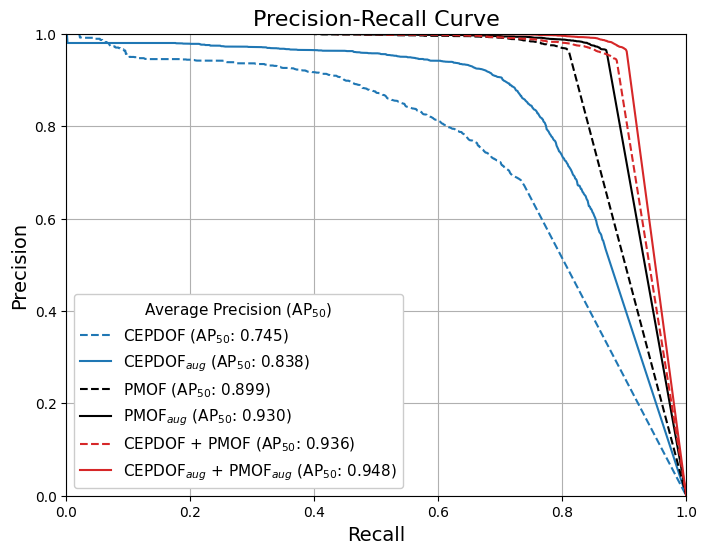

In [2]:
val_yaml = './yaml/Pval.yaml'
conf = 0.3

prruns_pval = [
    ### CEPDOF only
    PRRun('./runs/obb/20-m-1024-C-P/weights/epoch8.pt', 'CEPDOF',  "tab:blue", '--', val_yaml, conf),
    PRRun('./runs/obb/20-m-1024-CCa18-P/weights/epoch18.pt', r'CEPDOF$_{aug}$', "tab:blue", '-', val_yaml, conf),

    ### PMOF only
    PRRun('./runs/obb/20-m-1024-P-P/weights/epoch16.pt', 'PMOF', "black", '--', val_yaml, conf),
    PRRun('./runs/obb/20-m-1024-PPa18-P/weights/epoch4.pt', r'PMOF$_{aug}$', "black", '-', val_yaml, conf),
    
    ### CEPDOF & PMOF
    PRRun('./runs/obb/20-m-1024-CP-P/weights/epoch13.pt', 'CEPDOF + PMOF', "tab:red", '--', val_yaml, conf),
    PRRun('./runs/obb/20-m-1024-CCa18PPa18-P/weights/epoch7.pt', r'CEPDOF$_{aug}$ + PMOF$_{aug}$', "tab:red", '-', val_yaml, conf, device="0"),
]

# === ENSURE DATA ===
for run in prruns_pval:
    run.ensure_data()

PRPlotter(prruns_pval).plot()

10:18:27 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-C-P/weights/epoch0.pt
10:18:27 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-CCa18-P/weights/epoch10.pt
10:18:27 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-P-P/weights/epoch1.pt
10:18:27 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-PPa18-P/weights/epoch2.pt
10:18:27 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-CP-P/weights/epoch1.pt
10:18:27 | INFO | Using provided model checkpoint: runs/obb/20-m-1024-CCa18PPa18-P/weights/epoch7.pt
10:18:27 | INFO | Loaded cached PR results from runs/obb/20-m-1024-C-P/pr_20-m-1024-C-P_epoch0_Hval_30.json.
10:18:27 | INFO | Loaded cached PR results from runs/obb/20-m-1024-CCa18-P/pr_20-m-1024-CCa18-P_epoch10_Hval_30.json.
10:18:27 | INFO | Loaded cached PR results from runs/obb/20-m-1024-P-P/pr_20-m-1024-P-P_epoch1_Hval_30.json.
10:18:27 | INFO | Loaded cached PR results from runs/obb/20-m-1024-PPa18-P/pr_20-m-1024-PPa18

CEPDOF (AP$_{50}$: 90.9) - (P: 89.9) - (R: 85.5) - (F1: 87.7) - (FPS: 15567.8) 
LaTex-ready: CEPDOF & 90.9 & 89.9 & 85.5 & 87.7
CEPDOF$_{aug}$ (AP$_{50}$: 95.4) - (P: 87.7) - (R: 93.4) - (F1: 90.4) - (FPS: 15377.0) 
LaTex-ready: CEPDOF$_{aug}$ & 95.4 & 87.7 & 93.4 & 90.4
PMOF (AP$_{50}$: 60.1) - (P: 98.6) - (R: 21.6) - (F1: 35.4) - (FPS: 9043.7) 
LaTex-ready: PMOF & 60.1 & 98.6 & 21.6 & 35.4
PMOF$_{aug}$ (AP$_{50}$: 62.7) - (P: 97.9) - (R: 27.2) - (F1: 42.5) - (FPS: 15398.1) 
LaTex-ready: PMOF$_{aug}$ & 62.7 & 97.9 & 27.2 & 42.5
CEPDOF + PMOF (AP$_{50}$: 93.1) - (P: 92.0) - (R: 86.3) - (F1: 89.0) - (FPS: 15360.0) 
LaTex-ready: CEPDOF + PMOF & 93.1 & 92.0 & 86.3 & 89.0
CEPDOF$_{aug}$ + PMOF$_{aug}$ (AP$_{50}$: 96.5) - (P: 94.8) - (R: 92.7) - (F1: 93.7) - (FPS: 15415.2) 
LaTex-ready: CEPDOF$_{aug}$ + PMOF$_{aug}$ & 96.5 & 94.8 & 92.7 & 93.7


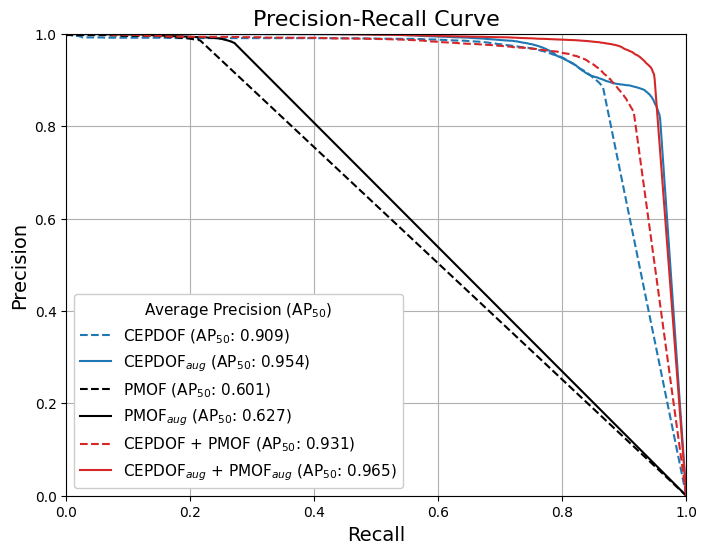

In [3]:
val_yaml = './yaml/Hval.yaml'
conf = 0.3

prruns_hval = [
    ### CEPDOF only
    PRRun('./runs/obb/20-m-1024-C-P/weights/epoch0.pt', 'CEPDOF',  "tab:blue", '--', val_yaml, conf),
    PRRun('./runs/obb/20-m-1024-CCa18-P/weights/epoch10.pt', r'CEPDOF$_{aug}$', "tab:blue", '-', val_yaml, conf),

    ### PMOF only
    PRRun('./runs/obb/20-m-1024-P-P/weights/epoch1.pt', 'PMOF', "black", '--', val_yaml, conf),
    PRRun('./runs/obb/20-m-1024-PPa18-P/weights/epoch2.pt', r'PMOF$_{aug}$', "black", '-', val_yaml, conf),
    
    ### CEPDOF & PMOF
    PRRun('./runs/obb/20-m-1024-CP-P/weights/epoch1.pt', 'CEPDOF + PMOF', "tab:red", '--', val_yaml, conf),
    PRRun('./runs/obb/20-m-1024-CCa18PPa18-P/weights/epoch7.pt', r'CEPDOF$_{aug}$ + PMOF$_{aug}$', "tab:red", '-', val_yaml, conf),
]

# === ENSURE DATA ===
for run in prruns_hval:
    run.ensure_data()

PRPlotter(prruns_hval).plot()

## Function for plotting directly in notebook for fast iterations in plot design.

In [ ]:
import matplotlib.pyplot as plt
from src import logger

from matplotlib import font_manager as fm

font_path = "../paper_plots/times.ttf" # Path to your font file

font_prop = fm.FontProperties(fname=font_path) # Create a font entry
font_name = font_prop.get_name() # Get the internal name (important!)
fm.fontManager.addfont(font_path) # Add it to the font manager
print("Registered font name:", font_name)


plt.rcParams.update({
    "text.usetex": False,  # LaTeX is not necessary, but can be enabled if needed
    #"font.family": "Times New Roman",  # Use IEEE recommended font
    "font.family": font_name,  # Use the registered font
    "font.size": 10,  # General font size
    "axes.labelsize": 10,  # Axis labels
    "axes.titlesize": 10,  # Title size
    "xtick.labelsize": 8,  # X-axis tick labels
    "ytick.labelsize": 8,  # Y-axis tick labels
    "legend.title_fontsize" : 8, # Titel of Legend
    "legend.fontsize": 8,  # Legend font size
    "figure.titlesize": 10,  # Figure title size
    "pdf.fonttype": 42,       
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.4,
})

import logging
logging.getLogger("fontTools.subset").setLevel(logging.ERROR)

Registered font name: Times New Roman


In [5]:
def prplotter(PRRun_instances, output_path=None, title=None):
    """Plot PR curves for all PRRun instances and save the figure."""
    plt.figure(figsize=(4,3), dpi=200)
    for run in PRRun_instances:
        ap50 = run.ap50*100
        plt.plot(run.recall, run.prec, label=fr"{run.plot_name}: AP$_{{50}}$ = {ap50:.1f}",
                 color=run.color, linestyle=run.linestyle, linewidth=1.4)
    
    plt.xlabel('Recall', color='black') 
    plt.ylabel('Precision', color='black') 
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.grid(True)
    plt.tight_layout(pad=0.05)
    plt.legend(loc='lower left', frameon=True, title=r'Average Precision (AP$_{{50}}$)', framealpha=0.9)
    if title:
        plt.title(title, fontsize=10)
    else:
        plt.title('Precision-Recall Performance Plot', fontsize=10)
    if output_path:
        plt.savefig(output_path, bbox_inches="tight", dpi=200, pad_inches=0.01)
        logger.info(f"Saved PR curve plot to {output_path}.")
    plt.show()

10:18:31 | INFO | Saved PR curve plot to ../paper_plots/PRcurve-Pval.svg.


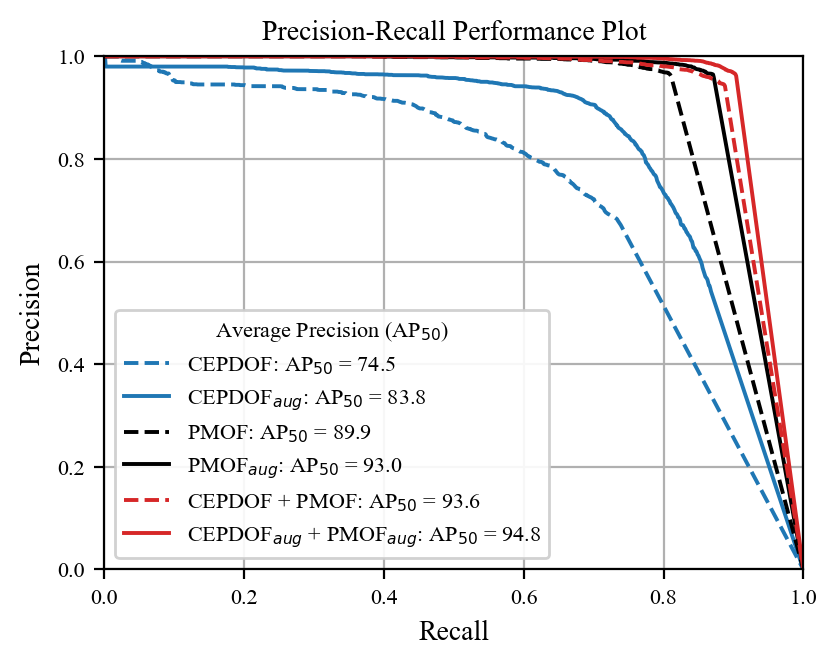

10:18:31 | INFO | Saved PR curve plot to ../paper_plots/PRcurve-Hval.svg.


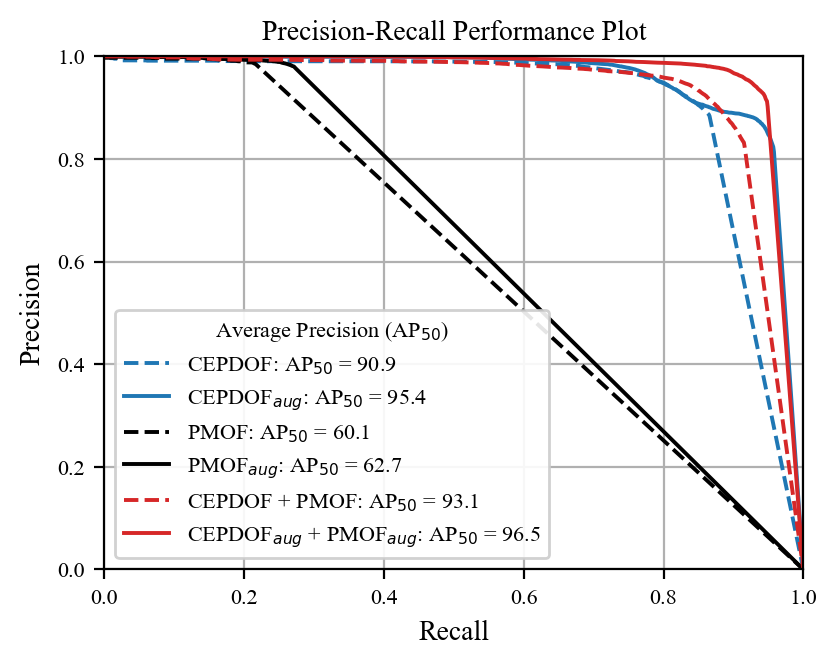

In [6]:
prplotter(prruns_pval,'../paper_plots/PRcurve-Pval.svg')
prplotter(prruns_hval,'../paper_plots/PRcurve-Hval.svg')

# Generate video of inference

In [ ]:
record_id = "rec30"
model_path = "./runs/obb/20-m-1024-CCa18PPa18-P/weights/epoch7.pt"

image_dir = Path(data_base_dir) / "images" / record_id
image_files = sorted(image_dir.glob("*.png"))

model = YOLO(model_path)

results = model.predict(source=image_dir, imgsz=640, show=False, save=False, verbose=False, classes=[0], stream=True, device=[0])

In [ ]:
frames = results_to_frames(results=results, data_base_dir=data_base_dir, viz_params=VIZ_PARAMS)

In [ ]:
frame_arrays = list(frames.values())
save_video(frame_arrays, output_path=f"../video_samples/{record_id}_prediction.mp4", fps=10, preview=True)

## Run for the Whole Validation Set

In [ ]:
for record_id in ["rec26", "rec27", "rec28", "rec29", "rec30"]:
    model_path = "./runs/obb/20-m-1024-CCa18PPa18-P/weights/epoch7.pt"
    
    image_dir = Path(data_base_dir) / "images" / record_id
    image_files = sorted(image_dir.glob("*.png"))
    
    yolo_base_dir = Path.cwd()
    model = YOLO(yolo_base_dir/model_path)
    
    results = model.predict(source=image_dir, imgsz=640, show=False, save=False, verbose=False, classes=[0], stream=True, device=[0])
    frames = results_to_frames(results=results, data_base_dir=data_base_dir, viz_params=VIZ_PARAMS)
    frame_arrays = list(frames.values())
    save_video(frame_arrays, fps=10, preview=True, output_path=f"../video_samples/{record_id}_prediction.mp4")